In [2]:
%pip install numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 6.9 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 19.0 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 18.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 23.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]
Note: you may need to restart the kernel to use updated packages.



--- Coordinates (1/T , log10(R)) ---

60 microamp:
(0.002874, 4.861335)
(0.002890, 4.910269)
(0.002907, 4.958245)
(0.002924, 4.975432)
(0.002941, 4.994903)
(0.002959, 4.993436)
(0.002976, 5.003604)
(0.002994, 5.010724)
(0.003012, 5.013539)
(0.003030, 5.021189)
(0.003049, 5.024622)
(0.003067, 5.028707)
(0.003086, 5.036096)
(0.003106, 5.036096)
(0.003125, 5.036762)
(0.003145, 5.044017)
(0.003165, 5.044017)
(0.003185, 5.047275)
(0.003205, 5.053719)
(0.003226, 5.054358)
(0.003247, 5.055633)

80→74 microamp corrected:
(0.002874, 4.860338)
(0.002890, 4.889302)
(0.002907, 4.907814)
(0.002924, 4.922985)
(0.002941, 4.938269)
(0.002959, 4.943247)
(0.002976, 4.947556)
(0.002994, 4.952429)
(0.003012, 4.959041)
(0.003030, 4.962014)
(0.003049, 4.963788)
(0.003067, 4.966142)
(0.003086, 4.969649)
(0.003106, 4.971392)
(0.003125, 4.978865)
(0.003145, 5.001172)
(0.003165, 5.000586)
(0.003185, 5.002925)
(0.003205, 5.003507)
(0.003226, 5.002925)
(0.003247, 5.002925)

--- RESULTS ---

Slope (60 µA) = 364.5

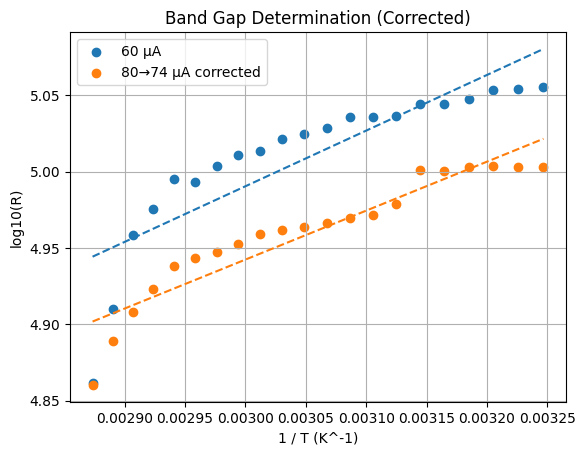

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# DATA
# -------------------------

T_c = np.array([
    75,73,71,69,67,65,63,61,59,57,55,53,51,
    49,47,45,43,41,39,37,35
])

V_60 = np.array([
    4.36,4.88,5.45,5.67,5.93,5.91,6.05,6.15,6.19,6.30,6.35,6.41,6.52,
    6.52,6.53,6.64,6.64,6.69,6.79,6.80,6.82
])

V_80 = np.array([
    5.8,6.2,6.47,6.7,6.94,7.02,7.09,7.17,7.28,7.33,7.36,7.40,7.46,
    7.49,7.62,7.42,7.41,7.45,7.46,7.45,7.45
])

# -------------------------
# CONSTANTS
# -------------------------

I_60 = 60e-6
I_80 = 80e-6
I_74 = 74e-6   # 🔥 NEW FIX

k = 8.620e-5  # eV/K

# -------------------------
# TEMPERATURE
# -------------------------

T_K = T_c + 273
inv_T = 1 / T_K

# -------------------------
# RESISTANCE CALCULATION
# -------------------------

R_60 = V_60 / I_60

# 🔥 Smart current handling for 80 µA data
R_80_corrected = []

for i in range(len(T_c)):
    if T_c[i] >= 47:   # above this → true 80 µA
        R_80_corrected.append(V_80[i] / I_80)
    else:              # below this → actually 74 µA
        R_80_corrected.append(V_80[i] / I_74)

R_80_corrected = np.array(R_80_corrected)

# -------------------------
# LOG VALUES
# -------------------------

logR_60 = np.log10(R_60)
logR_80 = np.log10(R_80_corrected)

# -------------------------
# PRINT COORDINATES
# -------------------------

print("\n--- Coordinates (1/T , log10(R)) ---\n")

print("60 microamp:")
for x, y in zip(inv_T, logR_60):
    print(f"({x:.6f}, {y:.6f})")

print("\n80→74 microamp corrected:")
for x, y in zip(inv_T, logR_80):
    print(f"({x:.6f}, {y:.6f})")

# -------------------------
# LINEAR FIT
# -------------------------

m60, c60 = np.polyfit(inv_T, logR_60, 1)
m80, c80 = np.polyfit(inv_T, logR_80, 1)

# -------------------------
# BAND GAP
# -------------------------

Eg_60 = 4.6052 * k * m60
Eg_80 = 4.6052 * k * m80
Eg_avg = (Eg_60 + Eg_80) / 2

# -------------------------
# RESULTS
# -------------------------

print("\n--- RESULTS ---\n")
print(f"Slope (60 µA) = {m60}")
print(f"Slope (corrected) = {m80}")

print(f"\nEg (60 µA) = {Eg_60} eV")
print(f"Eg (corrected) = {Eg_80} eV")

print(f"\n🔥 Average Eg = {Eg_avg} eV")

# -------------------------
# PLOT
# -------------------------

plt.scatter(inv_T, logR_60, label="60 µA")
plt.scatter(inv_T, logR_80, label="80→74 µA corrected")

plt.plot(inv_T, m60*inv_T + c60, linestyle='--')
plt.plot(inv_T, m80*inv_T + c80, linestyle='--')

plt.xlabel("1 / T (K^-1)")
plt.ylabel("log10(R)")
plt.title("Band Gap Determination (Corrected)")

plt.legend()
plt.grid()

plt.show()